# Regenerating training_df

In [4]:
import pandas as pd
import re
import numpy as np
def convert_clock_to_seconds(clock_str):
    match = re.match(r"PT(\d+)M(\d+)", clock_str)
    if match:
        minutes = int(match.group(1))
        seconds = int(match.group(2))
    
        return minutes * 60 + seconds
    
df = pd.read_csv("../data/pbp2024.csv")

gameids = df['gameid'].unique()
all_games_scoring = []

for game in gameids:
    single_game = df[df['gameid'] == game]

    # Keep ALL scoring rows first (including OT)
    full_scoring = single_game[single_game['h_pts'].notna()].copy()

    if full_scoring.empty:
        continue

    # Determine actual game winner from final score
    final_diff = ( full_scoring['h_pts'].iloc[-1] - full_scoring['a_pts'].iloc[-1] )

    home_win_bool = 1 if final_diff > 0 else 0

    # Now remove OT rows for feature generation
    scoring = full_scoring[full_scoring['period'] <= 4].copy()

    scoring['score_diff'] = scoring['h_pts'] - scoring['a_pts']
    scoring['quarter_seconds_remaining'] = ( scoring['clock'].apply(convert_clock_to_seconds) )

    scoring['game_seconds_remaining'] = ((4 - scoring['period']) * 720 + scoring['quarter_seconds_remaining'])

    scoring['home_win_bool'] = home_win_bool

    all_games_scoring.append(scoring[['gameid', 'score_diff', 'game_seconds_remaining', 'home_win_bool']])


training_df = pd.concat(
    all_games_scoring,
    ignore_index=True
)

# Logistic Regression Win Probability Model

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Interaction Feature

In [6]:
training_df['interaction'] = (
    training_df['score_diff']
    * training_df['game_seconds_remaining']
)

## Train-Test Split by Game

In [7]:
gameids = training_df['gameid'].unique()
train_games, test_games = train_test_split(gameids, test_size=0.2, random_state=42)

train_df = training_df[training_df['gameid'].isin(train_games)]
test_df = training_df[training_df['gameid'].isin(test_games)]

print("train shape:" ,train_df.shape)
print("test shape:" ,test_df.shape)

print("Train games:", train_df['gameid'].nunique())
print("Test games:", test_df['gameid'].nunique())


train shape: (134169, 5)
test shape: (33493, 5)
Train games: 1054
Test games: 264


Rows from the same game must not appear in both training and testing sets. Otherwise, the model could learn from nearly identical game states and produce overly optimistic performance estimates.

In [8]:
x_train = train_df[['score_diff', 'game_seconds_remaining', 'interaction']]
y_train = train_df['home_win_bool']


x_test = test_df[['score_diff', 'game_seconds_remaining', 'interaction']]
y_test = test_df['home_win_bool']

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

model = LogisticRegression()   # Create an instance of the Logistic Regression model
model.fit(x_train, y_train)    # Fit the model to the training data

predictions = model.predict(x_test)  # Make predictions on the test set

accuracy = accuracy_score(y_test, predictions)
print("Test set accuracy:", accuracy)


(134169, 3)
(134169,)
(33493, 3)
(33493,)
Test set accuracy: 0.7660705221986683


## Win Probability Function

In [9]:
def win_probability(score_diff, time_remaining):
    interaction = score_diff * time_remaining

    return model.predict_proba(
        [[score_diff, time_remaining, interaction]]
    )[0][1]

## Visualizing Model Behavior

c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarnin

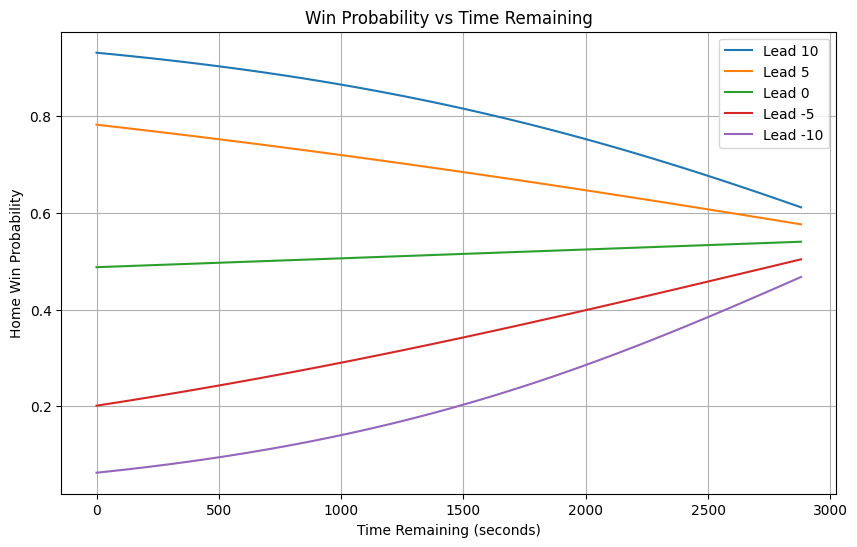

In [10]:
times = range(0, 48*60 + 1, 60)

leads = [10, 5, 0, -5, -10]

plt.figure(figsize=(10, 6))

for lead in leads:

    probs = []

    for time_left in times:
        probs.append(
            win_probability(lead, time_left)
        )

    plt.plot(
        list(times),
        probs,
        label=f"Lead {lead}"
    )

plt.xlabel("Time Remaining (seconds)")
plt.ylabel("Home Win Probability")
plt.title("Win Probability vs Time Remaining")

plt.legend()
plt.grid(True)

plt.savefig(
    "../images/win_probability_curves.png",
    bbox_inches="tight"
)

plt.show()